## **MiniProject 2: Training and Evaluation Practices**

Group: Aahaan Rawal, Ian Gifford, Nathan Hu

## Task 1: Logistic Regression with SGD

### Loading data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# set random seed for reproducibility
np.random.seed(2026)

**Place 'spambase.data' and 'spambase.names' from https://archive.ics.uci.edu/dataset/94/spambase into /content/ before proceeding.**

In [ ]:
# combine column names and values into a DataFrame
column_names = []
with open('spambase.names') as f:
  for line in f:
    line = line.strip()
    if line and not line.startswith("|"):
      name = line.split(":")[0]
      column_names.append(name)

# remove first line and add class label
column_names = column_names[1:] + ["class"]

df = pd.read_csv('spambase.data', header=None, names=column_names)
print(df.head().to_string())

   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  word_freq_order  word_freq_mail  word_freq_receive  word_freq_will  word_freq_people  word_freq_report  word_freq_addresses  word_freq_free  word_freq_business  word_freq_email  word_freq_you  word_freq_credit  word_freq_your  word_freq_font  word_freq_000  word_freq_money  word_freq_hp  word_freq_hpl  word_freq_george  word_freq_650  word_freq_lab  word_freq_labs  word_freq_telnet  word_freq_857  word_freq_data  word_freq_415  word_freq_85  word_freq_technology  word_freq_1999  word_freq_parts  word_freq_pm  word_freq_direct  word_freq_cs  word_freq_meeting  word_freq_original  word_freq_project  word_freq_re  word_freq_edu  word_freq_table  word_freq_conference  char_freq_;  char_freq_(  char_freq_[  char_freq_!  char_freq_$  char_freq_#  capital_run_length_average  capital_run_length_longest  capital_run_length_total  class
0            0.00        

In [ ]:
# print number of samples and features in the raw dataset
num_samples, num_features = df.shape
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features - 1}")

Number of samples: 4601
Number of features: 57


In [ ]:
# print feature datatypes, notice no categorical features
print(df.dtypes)

word_freq_make                float64
word_freq_address             float64
word_freq_all                 float64
word_freq_3d                  float64
word_freq_our                 float64
word_freq_over                float64
word_freq_remove              float64
word_freq_internet            float64
word_freq_order               float64
word_freq_mail                float64
word_freq_receive             float64
word_freq_will                float64
word_freq_people              float64
word_freq_report              float64
word_freq_addresses           float64
word_freq_free                float64
word_freq_business            float64
word_freq_email               float64
word_freq_you                 float64
word_freq_credit              float64
word_freq_your                float64
word_freq_font                float64
word_freq_000                 float64
word_freq_money               float64
word_freq_hp                  float64
word_freq_hpl                 float64
word_freq_ge

In [ ]:
print(df.describe())

       word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
count     4601.000000        4601.000000    4601.000000   4601.000000   
mean         0.104553           0.213015       0.280656      0.065425   
std          0.305358           1.290575       0.504143      1.395151   
min          0.000000           0.000000       0.000000      0.000000   
25%          0.000000           0.000000       0.000000      0.000000   
50%          0.000000           0.000000       0.000000      0.000000   
75%          0.000000           0.000000       0.420000      0.000000   
max          4.540000          14.280000       5.100000     42.810000   

       word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
count    4601.000000     4601.000000       4601.000000         4601.000000   
mean        0.312223        0.095901          0.114208            0.105295   
std         0.672513        0.273824          0.391441            0.401071   
min         0.000000        0.

### Create train/test split and standardize

In [ ]:
# separate features from label
target_col = 'class'
X = df.drop(columns=[target_col])
y = df[target_col]

In [ ]:
# create train (5%) and test (95%) split
def train_test_split(X, y, test_size=0.95):
  """
  splits data into training and test sets

  returns X_train, X_test, y_train, y_test
  """

  N = len(X)
  indices = np.random.permutation(N)

  n_test = int(N * test_size)
  test_idx = indices[:n_test]
  train_idx = indices[n_test:]

  if hasattr(X, 'iloc'):
    # DataFrame
    return X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]
  else:
    # ndarray
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 231 samples
Test set size: 4370 samples


In [ ]:
# standardize features
train_means = X_train.mean(axis=0)
train_stds = X_train.std(axis=0)
X_train_standard = (X_train - train_means) / train_stds
X_test_standard = (X_test - train_means) / train_stds

### Model Implementation

In [ ]:
# define the logistic function
logistic = lambda z: 1. / (1 + np.exp(-z))

In [ ]:
# define cross cross-entropy cost function
def cost_fn(X, y, w, lam):
  """
  calculates regularized cross-entropy cost
  convention: L_reg = mean_CE + lam * ||w||^2_2

  parameters:
  X: feature matrix of shape (N, D)
  y: label vector of shape (N,)
  w: weight vector of shape (D,)
  lam: regularization parameter

  returns:
  J: regularized cross-entropy cost
  """

  # compute logits (N,)
  z = X @ w

  # compute CE loss over all instances
  CE = np.mean(y * np.log1p(np.exp(-z)) + (1-y) * np.log1p(np.exp(z)))
  # compute L2 regularization term (excluding bias)
  L2 = lam * np.sum(w[:-1] ** 2)

  return CE + L2


In [ ]:
# define accuracy function
def accuracy(y_true, y_pred):
  return np.mean(y_true == y_pred)

In [ ]:
# define gradient function
def gradient(X, y, w, lam):
  """
  -calculates the gradient of the cost function with respect to the weights
  -lam is the L2 regularization parameter

  parameters:
  X: feature matrix of shape (N, D)
  y: label vector of shape (N,)
  w: weight vector of shape (D,)

  returns:
  grad: gradient vector, shape (D,)
  """
  N, D = X.shape

  # calculate gradient
  yhat = logistic(X @ w)
  grad = X.T @ (yhat - y) / N

  # L2 regularization (weight decay)
  # exclude bias weight
  grad[:-1] += 2 * lam * w[:-1]

  return grad

In [ ]:
# define the model class
class LogisticRegression:
  """
  Binary logistic regression trained with mini-batch SGD and L2 regularization
  The convention used for regularization:
    L_reg(w) = CE_mean(w) + lam * ||w||^2_2
  """
  def __init__(self, add_bias=True, lr=0.1, epochs=100, batch_size=32, lam=0.0):
    self.add_bias = add_bias
    self.lr = lr
    self.epochs = epochs
    self.batch_size = batch_size
    self.lam = lam
    self.w = None
    self.train_CE = []
    self.train_acc = []

  @staticmethod
  def add_bias_column(X):
    N, D = X.shape
    return np.column_stack([X, np.ones(N)])

  def fit(self, X, y):
    # convert to numpy if needed
    if hasattr(X, 'values'):
      X = X.values
    if hasattr(y, 'values'):
      y = y.values

    # handle 1D input
    if X.ndim == 1:
      X = X[:, None]

    N, D = X.shape

    # add bias column (column of ones)
    if self.add_bias:
      X = self.add_bias_column(X)
      D += 1

    # initialize weights
    self.w = np.zeros(D)
    # clear training history
    self.train_CE = []
    self.train_acc = []

    # loop a set number of epochs
    for epoch in range(self.epochs):
      # shuffle indices
      indices = np.arange(N)
      np.random.shuffle(indices)

      # loop through all batches
      for start in range(0, N, self.batch_size):
        end = min(start + self.batch_size, N)
        batch_indices = indices[start:end]
        X_batch = X[batch_indices]
        Y_batch = y[batch_indices]

        # use batch gradient to update weights
        grad = gradient(X_batch, Y_batch, self.w, self.lam)
        self.w = self.w - self.lr * grad

      # record training CE over full training set
      J_train = cost_fn(X, y, self.w, self.lam)
      self.train_CE.append(J_train)

      # record accuracy over full training set
      y_pred = (logistic(X @ self.w) >= 0.5).astype(int)
      self.train_acc.append(accuracy(y, y_pred))

    return self

  def predict_probability(self, X):
    if self.w is None:
      raise Exception("Model not fitted")

    # add bias column (column of ones)
    if self.add_bias:
      X = self.add_bias_column(X)

    return logistic(X @ self.w)

  def predict(self, X, threshold=0.5):
    return (self.predict_probability(X) >= threshold).astype(int)

  def plot_training_curve(self):
    if not self.train_CE:
      raise Exception("Model not fitted")

    plt.figure()
    plt.plot(np.arange(1, len(self.train_CE) + 1), self.train_CE)
    plt.xlabel("Epoch")
    plt.ylabel("Training Objective (CE + L2)")
    plt.title(
        f"Training Curve\n"
        f"lr={self.lr}, batch_size={self.batch_size}, "
        f"λ={self.lam}, epochs={self.epochs}"
    )

    plt.tight_layout()
    plt.grid(True)
    plt.show()

  def plot_accuracy_curve(self):
    if not self.train_acc:
      raise Exception("Model not fitted")

    plt.figure()
    plt.plot(np.arange(1, len(self.train_acc) + 1), self.train_acc)
    plt.xlabel("Epoch")
    plt.ylabel("Training Accuracy")
    plt.ylim(0.0, 1.0)
    plt.title(
        f"Training Accuracy\n"
        f"lr={self.lr}, batch_size={self.batch_size}, "
        f"λ={self.lam}, epochs={self.epochs}"
    )
    plt.tight_layout()
    plt.grid(True)
    plt.show()


### Training

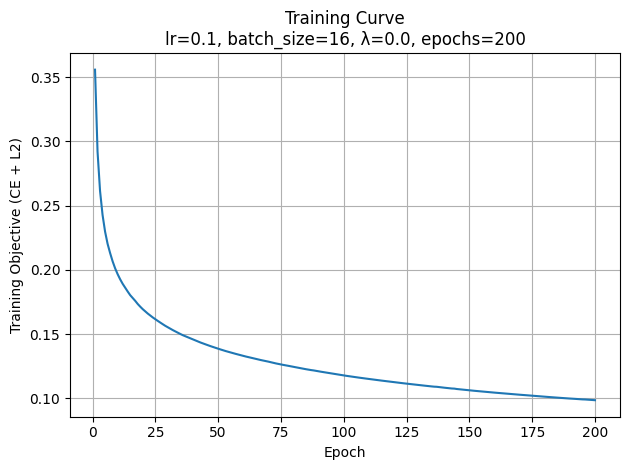

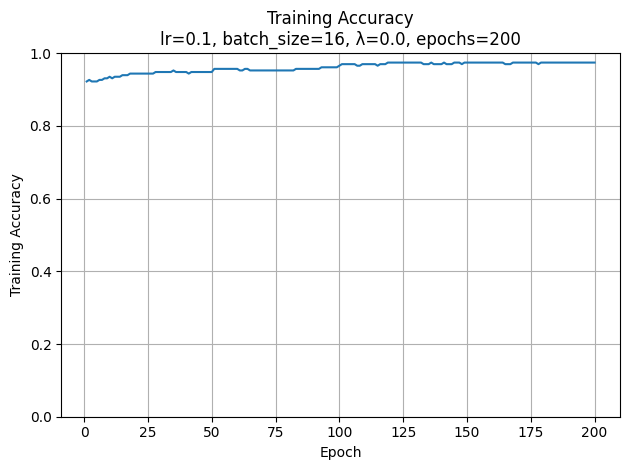

In [ ]:
# train model - no regularization
model = LogisticRegression(
  add_bias=True,
  lr=0.1,
  epochs=200,
  batch_size=16,
  lam=0.0
)
model.fit(X_train_standard, y_train)
model.plot_training_curve()
model.plot_accuracy_curve()

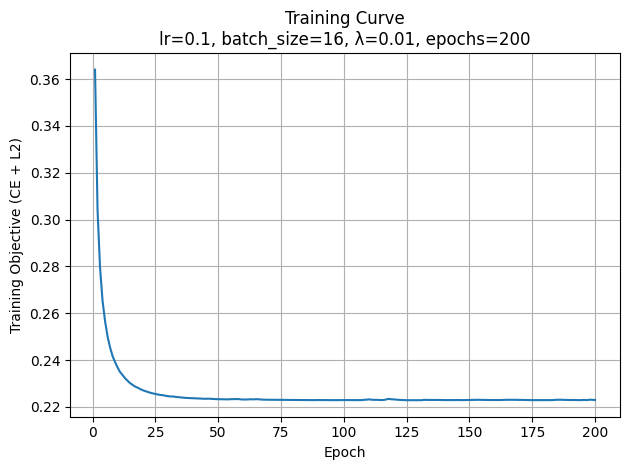

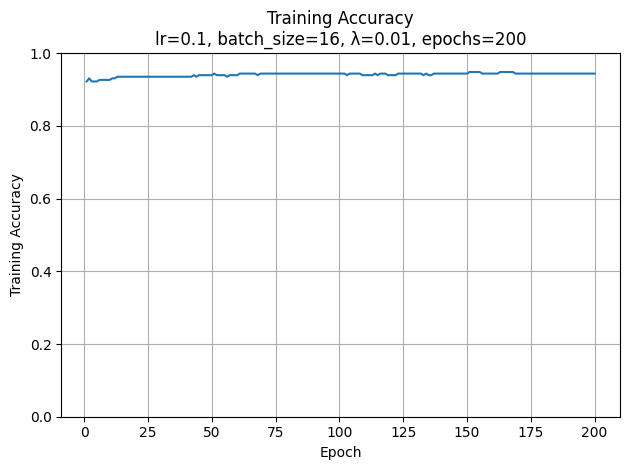

In [ ]:
# train model - regularization
model = LogisticRegression(
  add_bias=True,
  lr=0.1,
  epochs=200,
  batch_size=16,
  lam=1e-2
)
model.fit(X_train_standard, y_train)
model.plot_training_curve()
model.plot_accuracy_curve()

## Task 2: Hyperparameter Tuning with K-Fold Cross-Validation

K-Fold Split Implementation

In [ ]:
def k_fold_indices(N, K, rng):
    indices = rng.permutation(N)
    folds = np.array_split(indices, K)
    return folds

Evaluation Metrics

In [ ]:
def cross_entropy_loss(X, y, w):
  z = X @ w
  return np.mean(y * np.log1p(np.exp(-z)) + (1-y)*np.log1p(np.exp(z)))

def accuracy(y_true, y_pred):
  return np.mean(y_true == y_pred)

Cross-Validation Function

In [ ]:
def cross_validate(X, y, K, hyperparams, rng):
  N = len(X)
  folds = k_fold_indices(N, K, rng)

  results = []

  for params in hyperparams:
    fold_losses = []
    fold_accs = []

    for k in range(K):
      val_idx = folds[k]
      train_idx = np.concatenate([folds[i] for i in range(K) if i != k])

      X_train_fold = X[train_idx]
      y_train_fold = y[train_idx]
      X_val_fold = X[val_idx]
      y_val_fold = y[val_idx]

      #standardize using training fold only
      mean = X_train_fold.mean(axis=0)
      std = X_train_fold.std(axis=0)
      std[std == 0] = 1

      X_train_fold = (X_train_fold - mean) / std
      X_val_fold = (X_val_fold - mean) / std

      #train model
      model = LogisticRegression(lr = params["lr"], epochs = params["epochs"],
                                 batch_size = params["batch_size"], lam = params.get("lam", 0.0))

      model.fit(X_train_fold, y_train_fold)

      #add the bias manually for evaluation
      X_val_bias = model.add_bias_column(X_val_fold)

      val_loss = cross_entropy_loss(X_val_bias, y_val_fold, model.w)
      val_preds = model.predict(X_val_fold)

      fold_losses.append(val_loss)
      fold_accs.append(accuracy(y_val_fold, val_preds))

    results.append({"params" : params, "mean_loss" : np.mean(fold_losses),
                    "std_loss" : np.std(fold_losses), "mean_acc" : np.mean(fold_accs),
                    "std_acc" : np.std(fold_accs)})

  return results

Hyperparameter Grid

In [ ]:
hyperparams = []

learning_rates = [0.001, 0.01, 0.05]
batch_sizes = [1, 16, 64]
epochs_list = [50, 100, 200]
lams = [0.0, 1e-4, 1e-3]

for lr in learning_rates:
  for B in batch_sizes:
    for ep in epochs_list:
      for lam in lams:
        hyperparams.append({ "lr" : lr, "batch_size" : B, "epochs" : ep, "lam" : lam})

Run 5-Fold CV

In [ ]:
rng = np.random.default_rng(2026)

X_np = X_train.values
y_np = y_train.values

results = cross_validate(X_np, y_np, K = 5, hyperparams = hyperparams, rng = rng)

Creating the Summary Table

In [ ]:
df_results = pd.DataFrame(results)

df_results["lr"] = df_results["params"].apply(lambda x: x["lr"])
df_results["batch_size"] = df_results["params"].apply(lambda x: x["batch_size"])
df_results["epochs"] = df_results["params"].apply(lambda x: x["epochs"])
df_results["lam"] = df_results["params"].apply(lambda x: x["lam"])

df_results = df_results.drop(columns=["params"])

df_results = df_results.sort_values(by="mean_loss")

print(df_results.head(10))

    mean_loss  std_loss  mean_acc   std_acc     lr  batch_size  epochs     lam
48   0.349465  0.074679  0.896300  0.041433  0.010          64     100  0.0000
49   0.349545  0.074705  0.896300  0.041433  0.010          64     100  0.0001
50   0.349662  0.074461  0.896300  0.041433  0.010          64     100  0.0010
15   0.358809  0.065241  0.896300  0.041433  0.001          16     200  0.0000
16   0.359079  0.065755  0.896300  0.041433  0.001          16     200  0.0001
17   0.359305  0.065695  0.896300  0.041433  0.001          16     200  0.0010
45   0.387708  0.049144  0.887604  0.034071  0.010          64      50  0.0000
47   0.387822  0.048980  0.887604  0.034071  0.010          64      50  0.0010
46   0.387945  0.049273  0.891952  0.035618  0.010          64      50  0.0001
38   0.390643  0.155029  0.887604  0.053499  0.010          16      50  0.0010


Hyperparameter Sensitivity Plot

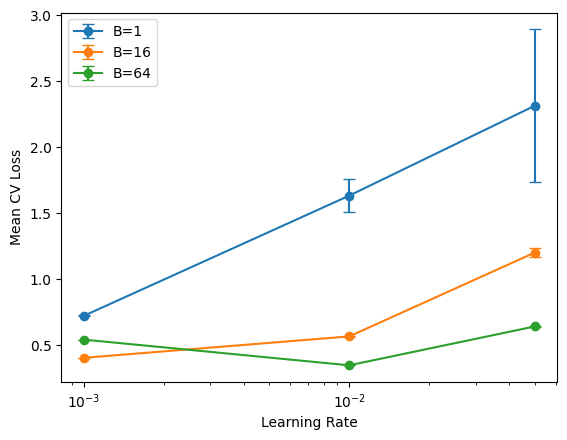

In [ ]:
for B in [1, 16, 64]:
  subset = df_results[(df_results.batch_size == B) & (df_results.epochs == 100)]

  agg = (subset.groupby("lr")["mean_loss"].agg(["mean", "std"]).reset_index().sort_values("lr"))

  plt.errorbar(agg["lr"], agg["mean"], yerr=agg["std"], marker="o", capsize=4, label=f"B={B}")

  #plt.plot(subset["lr"], subset["mean_loss"], marker="o", label=f"B={B}")

plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Mean CV Loss")
plt.legend()
plt.show()

## Task 3: Bias–Variance Trade-Off via λ Sweep (With K-Fold CV)

Fixed hyperparameters and setup

In [ ]:
fixed_lr = 0.1
fixed_batch_size = 16
fixed_epochs = 200
K_task3 = 5

# use train split from task 1 for cv/model selection
# keep test split held out.
X_train_np = X_train.values if hasattr(X_train, "values") else X_train
y_train_np = y_train.values if hasattr(y_train, "values") else y_train
X_test_np = X_test.values if hasattr(X_test, "values") else X_test
y_test_np = y_test.values if hasattr(y_test, "values") else y_test

lambda_grid = [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]

Helper functions for CV sweep

In [ ]:
def standardize_train_val(X_train_fold, X_val_fold):
  """
  standardize validation data using train-fold statistics only
  """
  mean = X_train_fold.mean(axis=0)
  std = X_train_fold.std(axis=0)
  std[std == 0] = 1
  X_train_std = (X_train_fold - mean) / std
  X_val_std = (X_val_fold - mean) / std
  return X_train_std, X_val_std

def evaluate_metrics(model, X_data, y_data):
  """
  compute cross-entropy and accuracy for fitted model
  """
  X_bias = model.add_bias_column(X_data) if model.add_bias else X_data
  ce = cross_entropy_loss(X_bias, y_data, model.w)
  y_pred = model.predict(X_data)
  acc = accuracy(y_data, y_pred)
  return ce, acc

def lambda_sweep_cv(X, y, K, lambda_values, lr, batch_size, epochs, seed=2026):
  """
  run k-fold cv for each lambda and collect train/val metrics
  """
  rng = np.random.default_rng(seed)
  folds = k_fold_indices(len(X), K, rng)
  rows = []

  for lam in lambda_values:
    train_ce_scores = []
    val_ce_scores = []
    train_acc_scores = []
    val_acc_scores = []

    for k in range(K):
      val_idx = folds[k]
      train_idx = np.concatenate([folds[i] for i in range(K) if i != k])

      X_tr = X[train_idx]
      y_tr = y[train_idx]
      X_val = X[val_idx]
      y_val = y[val_idx]

      X_tr_std, X_val_std = standardize_train_val(X_tr, X_val)

      model = LogisticRegression(
          add_bias=True,
          lr=lr,
          epochs=epochs,
          batch_size=batch_size,
          lam=lam
      )
      model.fit(X_tr_std, y_tr)

      tr_ce, tr_acc = evaluate_metrics(model, X_tr_std, y_tr)
      va_ce, va_acc = evaluate_metrics(model, X_val_std, y_val)

      train_ce_scores.append(tr_ce)
      val_ce_scores.append(va_ce)
      train_acc_scores.append(tr_acc)
      val_acc_scores.append(va_acc)

    rows.append({
        "lam": lam,
        "train_ce_mean": np.mean(train_ce_scores),
        "train_ce_std": np.std(train_ce_scores),
        "val_ce_mean": np.mean(val_ce_scores),
        "val_ce_std": np.std(val_ce_scores),
        "train_acc_mean": np.mean(train_acc_scores),
        "train_acc_std": np.std(train_acc_scores),
        "val_acc_mean": np.mean(val_acc_scores),
        "val_acc_std": np.std(val_acc_scores),
    })

  return pd.DataFrame(rows).sort_values(by="val_ce_mean")

Run lambda sweep with K-fold CV

In [ ]:
task3_results = lambda_sweep_cv(
    X=X_train_np,
    y=y_train_np,
    K=K_task3,
    lambda_values=lambda_grid,
    lr=fixed_lr,
    batch_size=fixed_batch_size,
    epochs=fixed_epochs,
    seed=2026
)

print("Task 3 CV results (sorted by validation cross-entropy):")
print(task3_results.to_string(index=False))

# choose best lambda by lowest mean validation CE
best_row = task3_results.iloc[0]
best_lam = float(best_row["lam"])
print(f"\nSelected lambda (best CV val CE): {best_lam}")

Task 3 CV results (sorted by validation cross-entropy):
     lam  train_ce_mean  train_ce_std  val_ce_mean  val_ce_std  train_acc_mean  train_acc_std  val_acc_mean  val_acc_std
0.100000       0.281014      0.005916     0.388774    0.094181        0.916675       0.011591      0.861425     0.029672
1.000000       0.485731      0.003719     0.487704    0.030304        0.819277       0.024464      0.818316     0.051952
0.010000       0.154791      0.009742     0.836680    0.934967        0.952380       0.012519      0.878723     0.040480
0.001000       0.093890      0.011013     1.558516    2.138162        0.972938       0.006866      0.878723     0.035504
0.000100       0.083704      0.011413     1.828419    2.548090        0.976181       0.008818      0.865680     0.035140
0.000001       0.082560      0.011403     1.852117    2.578664        0.977262       0.007988      0.865680     0.032339
0.000010       0.082695      0.011429     1.852275    2.578529        0.977262       0.007988    

Plot CE and accuracy vs lambda

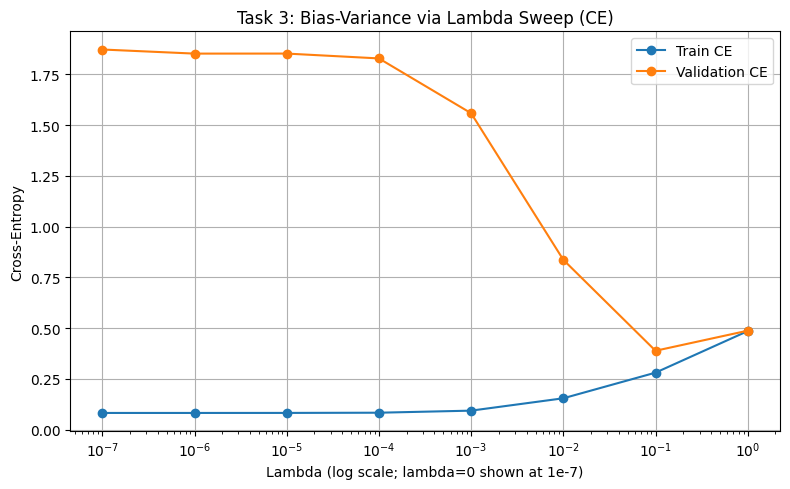

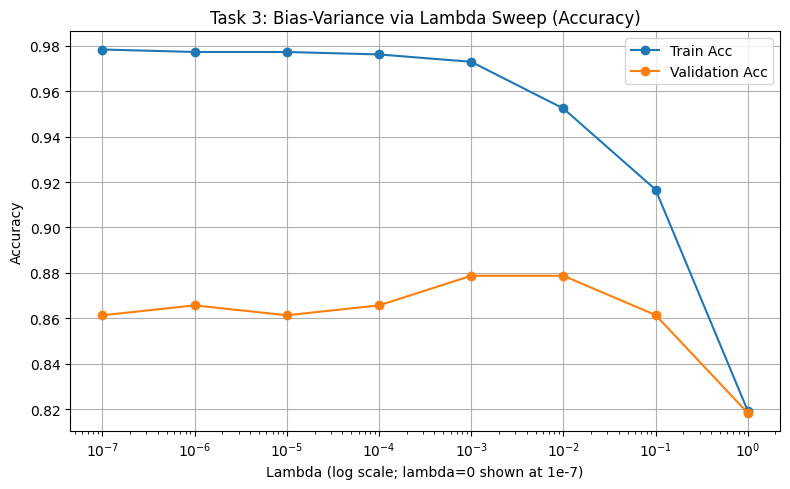

In [ ]:
plot_lams = task3_results["lam"].values.copy()
plot_lams[plot_lams == 0.0] = 1e-7
order = np.argsort(plot_lams)
plot_lams = plot_lams[order]

# plot cross-entropy vs lambda
plt.figure(figsize=(8, 5))
plt.plot(plot_lams, task3_results["train_ce_mean"].values[order], marker="o", label="Train CE")
plt.plot(plot_lams, task3_results["val_ce_mean"].values[order], marker="o", label="Validation CE")
plt.xscale("log")
plt.xlabel("Lambda (log scale; lambda=0 shown at 1e-7)")
plt.ylabel("Cross-Entropy")
plt.title("Task 3: Bias-Variance via Lambda Sweep (CE)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# plot accuracy vs lambda
plt.figure(figsize=(8, 5))
plt.plot(plot_lams, task3_results["train_acc_mean"].values[order], marker="o", label="Train Acc")
plt.plot(plot_lams, task3_results["val_acc_mean"].values[order], marker="o", label="Validation Acc")
plt.xscale("log")
plt.xlabel("Lambda (log scale; lambda=0 shown at 1e-7)")
plt.ylabel("Accuracy")
plt.title("Task 3: Bias-Variance via Lambda Sweep (Accuracy)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



Retrain with best lambda

In [ ]:
train_mean = X_train_np.mean(axis=0)
train_std = X_train_np.std(axis=0)
train_std[train_std == 0] = 1

X_train_final = (X_train_np - train_mean) / train_std
X_test_final = (X_test_np - train_mean) / train_std

final_model = LogisticRegression(
    add_bias=True,
    lr=fixed_lr,
    epochs=fixed_epochs,
    batch_size=fixed_batch_size,
    lam=best_lam
)
final_model.fit(X_train_final, y_train_np)


Final held-out test evaluation

In [ ]:
train_ce_final, train_acc_final = evaluate_metrics(final_model, X_train_final, y_train_np)
test_ce_final, test_acc_final = evaluate_metrics(final_model, X_test_final, y_test_np)

print("\nTask 3 final evaluation:")
print(f"Train CE: {train_ce_final:.6f}, Train Acc: {train_acc_final:.4f}")
print(f"Test  CE: {test_ce_final:.6f}, Test  Acc: {test_acc_final:.4f}")


Task 3 final evaluation:
Train CE: 0.293239, Train Acc: 0.8961
Test  CE: 0.348216, Test  Acc: 0.8865


## Task 4: L1-Regularized Logistic Regression and the Regularization Path (Using scikit-learn)

In [ ]:
# import necessary scikit-learn tools
from sklearn.linear_model import LogisticRegression as LogReg
from sklearn.linear_model import LogisticRegressionCV as LogRegCV

In [ ]:
# regularization path parameters
Cs = np.logspace(-4, 4, 30) # grid of regularization strengths (inverse)
top_k = 10                  # show only the top-k regularization paths
feature_names = X_train.columns.to_numpy()

In [ ]:
# define the base model
base_model = LogReg(
    penalty="l1",
    solver="saga",
    max_iter=5000,
    tol=1e-3,
    warm_start=True,
    random_state=2026
)

In [ ]:
# train a separate model for each C value in Cs

# keep track of metrics we graph later
coefs = []
nonzero_counts = []
train_accs = []

for C in Cs:
  base_model.set_params(C=C)
  base_model.fit(X_train_standard, y_train)

  coef = base_model.coef_.copy()
  coefs.append(coef)

  nonzero_counts.append(np.sum(coef != 0))

  yhat_train = base_model.predict(X_train_standard)
  train_accs.append(accuracy(y_train, yhat_train))

coefs = np.vstack(coefs)
nonzero_counts = np.array(nonzero_counts)
train_accs = np.array(train_accs)

# only plot top-k coefficients by absolute magnitude
top_idx = np.argsort(
    np.max(np.abs(coefs), axis=0)
)[::-1][:top_k]


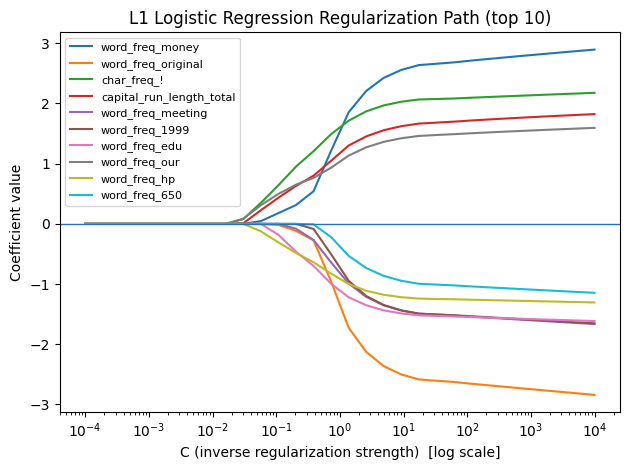

In [ ]:
# regularization path of coefficients

plt.figure()
for i in top_idx:
    plt.plot(Cs, coefs[:, i], label=feature_names[i])
plt.xscale("log")
plt.axhline(0, linewidth=1)
plt.xlabel("C (inverse regularization strength)  [log scale]")
plt.ylabel("Coefficient value")
plt.title(f"L1 Logistic Regression Regularization Path (top {top_k})")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

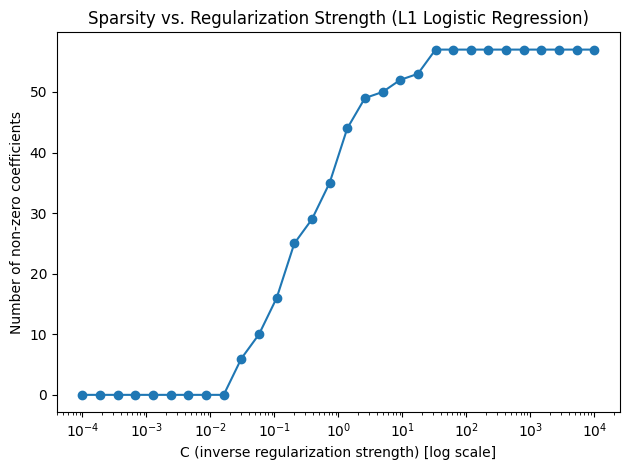

In [ ]:
# sparsity plot

plt.figure()
plt.plot(Cs, nonzero_counts, marker="o")
plt.xscale("log")
plt.xlabel("C (inverse regularization strength) [log scale]")
plt.ylabel("Number of non-zero coefficients")
plt.title("Sparsity vs. Regularization Strength (L1 Logistic Regression)")
plt.tight_layout()
plt.show()

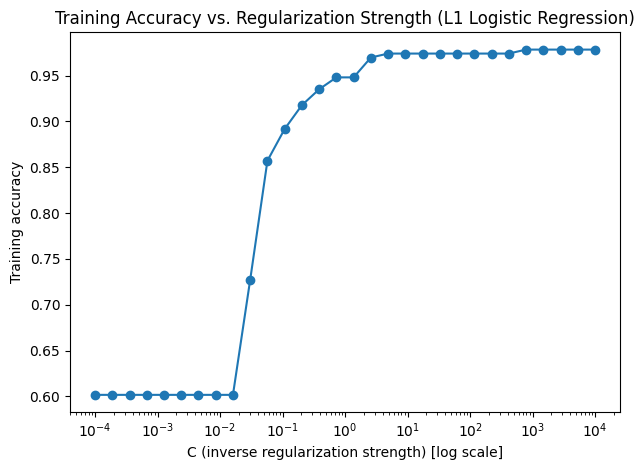

In [ ]:
# training accuracy vs. regularization strength

plt.figure()
plt.plot(Cs, train_accs, marker="o")
plt.xscale("log")
plt.xlabel("C (inverse regularization strength) [log scale]")
plt.ylabel("Training accuracy")
plt.title("Training Accuracy vs. Regularization Strength (L1 Logistic Regression)")
plt.tight_layout()
plt.show()

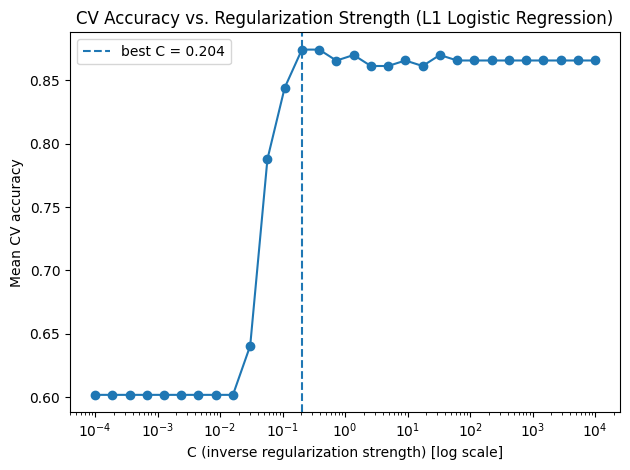

In [ ]:
# CV performance vs. C

CV_base_model = LogRegCV(
    penalty="l1",
    solver="saga",
    Cs=Cs,
    cv=5,
    scoring="accuracy",
    max_iter=5000,
    tol=1e-3,
    refit=True,
    n_jobs=-1,
    random_state=2026
)

CV_base_model.fit(X_train_standard, y_train)
scores_arr = np.array(CV_base_model.scores_[1])

# average fold accuracies for each C
mean_cv_acc = scores_arr.mean(axis=0)

best_C = float(np.ravel(CV_base_model.C_)[0])

plt.figure()
plt.plot(Cs, mean_cv_acc, marker="o")
plt.xscale("log")
plt.xlabel("C (inverse regularization strength) [log scale]")
plt.ylabel("Mean CV accuracy")
plt.title("CV Accuracy vs. Regularization Strength (L1 Logistic Regression)")
plt.axvline(best_C, linestyle="--", label=f"best C = {best_C:.3g}")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# evaluate best model on test set

yhat_test = CV_base_model.predict(X_test_standard)
print("Best C:", best_C)
print("Test accuracy (best CV model):", accuracy(y_test, yhat_test))
print("Non-zero coefficients at best C:", np.sum(CV_base_model.coef_.ravel() != 0))

Best C: 0.20433597178569418
Test accuracy (best CV model): 0.8709382151029749
Non-zero coefficients at best C: 25
